In [1]:
%reload_ext autoreload
%autoreload 2
import os
import sinter
import matplotlib.pyplot as plt
import numpy as np
import torch

from qecdec import RotatedSurfaceCode_Memory
from qecdec import BPDecoder, DMemBPDecoder
from qecdec.sinter_wrapper import SinterDecoderWrapper


In [11]:
# ============ Configuration (edit these parameters) ============
# Note: Learned gamma is code-specific. d and rounds must match the checkpoint's training config.
CHECKPOINT_PATH = "../scripts/lightning_logs/version_1/checkpoints/epoch=9-step=5520.ckpt"
d = 7
rounds = 7
basis = "Z"
p_list = [0.004, 0.006, 0.008, 0.01, 0.012]
max_iter = 50
max_shots = 10_000_000
max_errors = 100
num_workers = os.cpu_count() - 1 if os.cpu_count() > 1 else 1

In [12]:
# Load checkpoint and extract gamma
ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
gamma = ckpt["state_dict"]["decoder.gamma"].numpy().astype(np.float64)

# Verify gamma shape matches the code (d, rounds)
expmt_check = RotatedSurfaceCode_Memory(
    d=d, rounds=rounds, basis=basis,
    data_qubit_error_rate=0.01, meas_error_rate=0.01,
)
assert gamma.shape == (expmt_check.chkmat.shape[1],), (
    f"gamma shape {gamma.shape} does not match num_vars {expmt_check.chkmat.shape[1]} "
    f"for d={d}, rounds={rounds}. Ensure d and rounds match the checkpoint's training config."
)

In [13]:
def generate_sinter_tasks_and_custom_decoders():
    tasks = []
    custom_decoders = {}
    for p in p_list:
        expmt = RotatedSurfaceCode_Memory(
            d=d,
            rounds=rounds,
            basis=basis,
            data_qubit_error_rate=p,
            meas_error_rate=p,
        )
        # MWPM
        tasks.append(sinter.Task(
            circuit=expmt.circuit,
            detector_error_model=expmt.dem,
            decoder="pymatching",
            json_metadata={"d": d, "p": p, "decoder": "pymatching"},
        ))
        # Vanilla BP
        bp = BPDecoder(expmt.chkmat, expmt.prior, max_iter=max_iter)
        custom_decoder_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[custom_decoder_id] = SinterDecoderWrapper(bp, expmt.obsmat)
        tasks.append(sinter.Task(
            circuit=expmt.circuit,
            detector_error_model=expmt.dem,
            decoder=custom_decoder_id,
            json_metadata={"d": d, "p": p, "decoder": "bp"},
        ))
        # Learned DMemBP
        dmembp = DMemBPDecoder(
            expmt.chkmat, expmt.prior,
            gamma=gamma, max_iter=max_iter,
        )
        custom_decoder_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[custom_decoder_id] = SinterDecoderWrapper(dmembp, expmt.obsmat)
        tasks.append(sinter.Task(
            circuit=expmt.circuit,
            detector_error_model=expmt.dem,
            decoder=custom_decoder_id,
            json_metadata={"d": d, "p": p, "decoder": "learned_dmembp"},
        ))
    return tasks, custom_decoders

tasks, custom_decoders = generate_sinter_tasks_and_custom_decoders()

In [14]:
sinter_stats = sinter.collect(
    num_workers=num_workers,
    max_shots=max_shots,
    max_errors=max_errors,
    tasks=tasks,
    custom_decoders=custom_decoders,
    print_progress=True,
)

Starting 7 workers...


15 tasks left:
  workers          decoder eta shots_left errors_left json_metadata                     
        1       pymatching   ?   10000000         100 d=7,p=0.004,decoder=pymatching    
        1 custom_decoder_0   ?   10000000         100 d=7,p=0.004,decoder=bp            
        1 custom_decoder_1   ?   10000000         100 d=7,p=0.004,decoder=learned_dmembp
        1       pymatching <1m    9998703          99 d=7,p=0.006,decoder=pymatching    
        1 custom_decoder_2   ?   10000000         100 d=7,p=0.006,decoder=bp            
        1 custom_decoder_3   ?   10000000         100 d=7,p=0.006,decoder=learned_dmembp
        1       pymatching   ?   10000000         100 d=7,p=0.008,decoder=pymatching    
        0 custom_decoder_4 ?·∞   10000000         100 d=7,p=0.008,decoder=bp            
        0 custom_decoder_5 ?·∞   10000000         100 d=7,p=0.008,decoder=learned_dmembp
        0       pymatching ?·∞   10000000         100 d=7,p=0.01,decoder=pymatching     
      

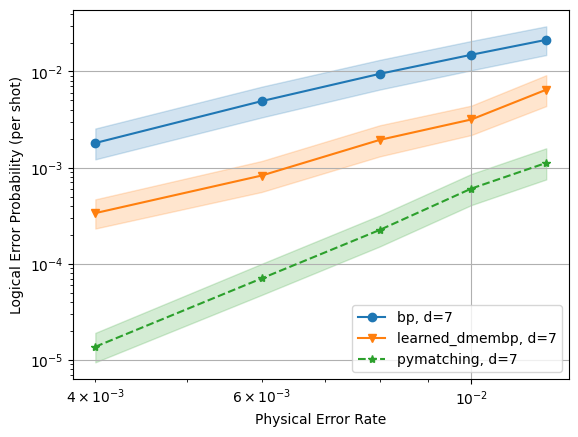

In [15]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=sinter_stats,
    group_func=lambda stat: f"{stat.json_metadata['decoder']}, d={stat.json_metadata['d']}",
    x_func=lambda stat: stat.json_metadata["p"],
    plot_args_func=lambda index, group_key: {
        "linestyle": "solid" if "bp" in group_key or "dmembp" in group_key else "dashed",
    },
)
ax.loglog()
ax.grid()
ax.set_ylabel("Logical Error Probability (per shot)")
ax.set_xlabel("Physical Error Rate")
ax.legend()